
# GVH Diagonal Cubic 0.2.4 — Reference Validation
## Validation quantitative sur systèmes géométriques et gravitationnels de référence

**Auteur : Charlemagne O Laurince**

---

## Objectif

Ce notebook valide quantitativement le moteur développé dans :

- `GVH_Diagonal_Cubic_0.2.1_Metric_Foundations.ipynb`
- `GVH_Diagonal_Cubic_0.2.2_Christoffel_Symbols.ipynb`
- `GVH_Diagonal_Cubic_0.2.3_Geodesic_Integrator.ipynb`

La chaîne testée est :

\[
g_{\mu\nu}
\longrightarrow
\Gamma^\mu_{\alpha\beta}
\longrightarrow
X^\mu(\lambda).
\]

Les références sont :

1. mouvement rectiligne de Minkowski ;
2. géodésiques de grand cercle sur une sphère ;
3. orbite newtonienne de Kepler ;
4. précession relativiste de Mercure ;
5. covariance sous rotation ;
6. convergence numérique.

---

## Principe de décision

Une métrique GVH candidate ne peut être étudiée qu'après validation du moteur sur les références établies.

Les statuts utilisés sont :

- **PASS** : critère quantitatif satisfait ;
- **CHECK** : résultat exploitable, mais précision insuffisante ;
- **FAIL** : incompatibilité ou erreur persistante.

---

## Limite conceptuelle

La sphère est traitée comme une **sous-variété contrainte** :

\[
x^2+y^2+z^2=R^2,
\]

alors que Newton et Schwarzschild représentent une dynamique gravitationnelle.

Ces mécanismes utilisent tous des trajectoires géométriques, mais ne doivent pas être confondus.


In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.integrate import solve_ivp
from scipy.optimize import minimize_scalar

np.set_printoptions(precision=10, suppress=True)

G = 6.67430e-11
c = 299_792_458.0
M_SUN = 1.98847e30
R_EARTH = 6_371_000.0

def rel_error(value, reference, floor=1e-30):
    return abs(value-reference) / max(abs(reference), floor)

print("Environnement chargé.")


Environnement chargé.



# 1. Référence de Minkowski

En espace-temps plat :

\[
\Gamma^\mu_{\alpha\beta}=0,
\]

et la géodésique exacte est :

\[
X^\mu(\lambda)=X_0^\mu+U_0^\mu\lambda.
\]

Ce test contrôle l'intégrateur indépendamment de toute courbure.


In [2]:

def minkowski_rhs(lam, state):
    dstate = np.zeros_like(state)
    dstate[:4] = state[4:]
    return dstate

X0 = np.array([0.0, 2.0, -3.0, 1.5])
U0 = np.array([1.01, 0.04, -0.02, 0.01])
state0 = np.concatenate([X0, U0])

lam_eval = np.linspace(0.0, 1000.0, 2000)
sol_mink = solve_ivp(
    minkowski_rhs,
    (lam_eval[0], lam_eval[-1]),
    state0,
    t_eval=lam_eval,
    method="DOP853",
    rtol=1e-12,
    atol=1e-14
)

X_exact = X0[:, None] + U0[:, None]*lam_eval[None, :]
mink_error = np.max(np.linalg.norm(sol_mink.y[:4]-X_exact, axis=0))

print("Erreur maximale Minkowski :", mink_error)


Erreur maximale Minkowski : 5.705286514767815e-13



# 2. Géodésique sur une sphère

Pour deux vecteurs unitaires \(\mathbf p_0\) et \(\mathbf p_1\), la géodésique de grand cercle est donnée par l'interpolation sphérique :

\[
\mathbf p(s)
=
\frac{\sin[(1-s)\Omega]}{\sin\Omega}\mathbf p_0
+
\frac{\sin(s\Omega)}{\sin\Omega}\mathbf p_1,
\]

avec

\[
\Omega=\arccos(\mathbf p_0\cdot\mathbf p_1).
\]

Nous vérifions :

- la contrainte \(||\mathbf p||=1\) ;
- la longueur numérique ;
- l'accord avec \(R\Omega\) ;
- l'invariance sous rotation.


In [3]:

def latlon_to_unit(lat_deg, lon_deg):
    lat, lon = np.radians([lat_deg, lon_deg])
    return np.array([
        np.cos(lat)*np.cos(lon),
        np.cos(lat)*np.sin(lon),
        np.sin(lat)
    ])

def slerp(p0, p1, n=5000):
    p0 = np.asarray(p0, dtype=float)
    p1 = np.asarray(p1, dtype=float)
    p0 /= np.linalg.norm(p0)
    p1 /= np.linalg.norm(p1)
    omega = np.arccos(np.clip(np.dot(p0, p1), -1.0, 1.0))
    s = np.linspace(0.0, 1.0, n)
    if omega < 1e-14:
        return np.repeat(p0[None, :], n, axis=0), omega
    pts = (
        np.sin((1-s)*omega)[:, None]*p0
        + np.sin(s*omega)[:, None]*p1
    ) / np.sin(omega)
    return pts, omega

p0 = latlon_to_unit(46.8772, -96.7898)
p1 = latlon_to_unit(48.8566, 2.3522)

sphere_path, omega = slerp(p0, p1)
sphere_xyz = R_EARTH*sphere_path

segment_lengths = np.linalg.norm(np.diff(sphere_xyz, axis=0), axis=1)
sphere_length_num = segment_lengths.sum()
sphere_length_ref = R_EARTH*omega

sphere_constraint_error = np.max(
    np.abs(np.linalg.norm(sphere_path, axis=1)-1.0)
)
sphere_length_rel_error = rel_error(sphere_length_num, sphere_length_ref)

print("Longueur analytique (km) :", sphere_length_ref/1000)
print("Longueur numérique (km)  :", sphere_length_num/1000)
print("Erreur relative longueur :", sphere_length_rel_error)
print("Erreur de contrainte     :", sphere_constraint_error)


Longueur analytique (km) : 6830.950204495575
Longueur numérique (km)  : 6830.950191402229
Erreur relative longueur : 1.9167678590212912e-09
Erreur de contrainte     : 3.3306690738754696e-16


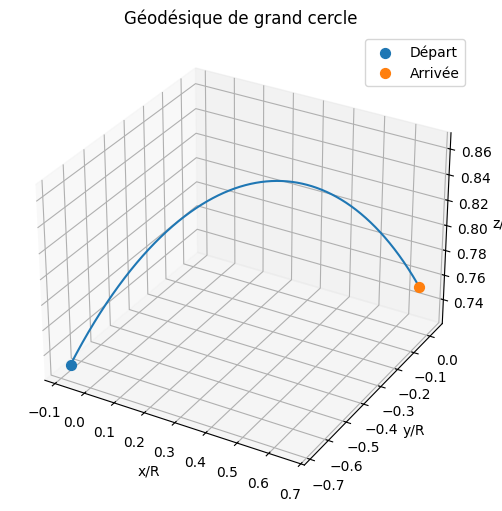

In [4]:

fig = plt.figure(figsize=(7,6))
ax = fig.add_subplot(111, projection="3d")
ax.plot(sphere_path[:,0], sphere_path[:,1], sphere_path[:,2])
ax.scatter(*p0, s=50, label="Départ")
ax.scatter(*p1, s=50, label="Arrivée")
ax.set_xlabel("x/R")
ax.set_ylabel("y/R")
ax.set_zlabel("z/R")
ax.set_title("Géodésique de grand cercle")
ax.legend()
plt.show()



# 3. Orbite newtonienne de Kepler

Nous intégrons :

\[
\ddot{\mathbf r}
=
-\frac{\mu}{r^3}\mathbf r,
\qquad
\mu=GM.
\]

Les références analytiques sont :

\[
\varepsilon
=
\frac{v^2}{2}-\frac{\mu}{r},
\]

\[
a=-\frac{\mu}{2\varepsilon},
\]

\[
T=2\pi\sqrt{\frac{a^3}{\mu}}.
\]

Nous mesurons :

- dérive de l'énergie ;
- dérive du moment cinétique ;
- période numérique ;
- erreur de fermeture orbitale.


In [5]:

MU_SUN = G*M_SUN

def newton_rhs(t, y, mu=MU_SUN):
    rvec = y[:3]
    vvec = y[3:]
    r = np.linalg.norm(rvec)
    avec = -mu*rvec/r**3
    return np.concatenate([vvec, avec])

a_ref = 57.909e9
e_ref = 0.205630
r_peri = a_ref*(1-e_ref)
v_peri = np.sqrt(MU_SUN*(1+e_ref)/(a_ref*(1-e_ref)))

y0_newton = np.array([r_peri, 0.0, 0.0, 0.0, v_peri, 0.0])
T_ref = 2*np.pi*np.sqrt(a_ref**3/MU_SUN)

t_eval = np.linspace(0.0, 3*T_ref, 12000)
sol_newton = solve_ivp(
    newton_rhs,
    (t_eval[0], t_eval[-1]),
    y0_newton,
    t_eval=t_eval,
    method="DOP853",
    rtol=1e-11,
    atol=1e-12,
    max_step=T_ref/2000
)

rvec = sol_newton.y[:3].T
vvec = sol_newton.y[3:].T
rnorm = np.linalg.norm(rvec, axis=1)
v2 = np.sum(vvec*vvec, axis=1)

energy = 0.5*v2 - MU_SUN/rnorm
hvec = np.cross(rvec, vvec)
hmag = np.linalg.norm(hvec, axis=1)

energy_rel_drift = (energy.max()-energy.min())/abs(energy.mean())
h_rel_drift = (hmag.max()-hmag.min())/abs(hmag.mean())

print("Dérive relative énergie :", energy_rel_drift)
print("Dérive relative moment cinétique :", h_rel_drift)


Dérive relative énergie : 9.77888294439664e-15
Dérive relative moment cinétique : 5.344586937567279e-15


In [6]:

# Détection raffinée des périastres par minimisation locale
peri_times = []

for i in range(1, len(rnorm)-1):
    if rnorm[i] < rnorm[i-1] and rnorm[i] < rnorm[i+1]:
        t_left, t_right = t_eval[i-1], t_eval[i+1]

        # interpolation dense via la solution
        dense = solve_ivp(
            newton_rhs,
            (t_left, t_right),
            sol_newton.y[:, i-1],
            dense_output=True,
            method="DOP853",
            rtol=1e-12,
            atol=1e-13
        )

        result = minimize_scalar(
            lambda tt: np.linalg.norm(dense.sol(tt)[:3]),
            bounds=(t_left, t_right),
            method="bounded",
            options={"xatol": 1e-8}
        )
        peri_times.append(result.x)

peri_times = np.array(peri_times)
periods_num = np.diff(peri_times)
T_num = periods_num.mean()

period_rel_error = rel_error(T_num, T_ref)

# Fermeture après une période théorique par interpolation
sol_dense = solve_ivp(
    newton_rhs,
    (0.0, T_ref),
    y0_newton,
    dense_output=True,
    method="DOP853",
    rtol=1e-12,
    atol=1e-13,
    max_step=T_ref/3000
)
state_T = sol_dense.sol(T_ref)
closure_position_rel = (
    np.linalg.norm(state_T[:3]-y0_newton[:3]) / np.linalg.norm(y0_newton[:3])
)
closure_velocity_rel = (
    np.linalg.norm(state_T[3:]-y0_newton[3:]) / np.linalg.norm(y0_newton[3:])
)

print("Période analytique (jours) :", T_ref/86400)
print("Période numérique (jours)  :", T_num/86400)
print("Erreur relative période    :", period_rel_error)
print("Erreur fermeture position  :", closure_position_rel)
print("Erreur fermeture vitesse   :", closure_velocity_rel)


Période analytique (jours) : 87.9676196837673
Période numérique (jours)  : 87.96761968341634
Erreur relative période    : 3.989525688929235e-12
Erreur fermeture position  : 4.014649715636811e-14
Erreur fermeture vitesse   : 3.4965394382309823e-14


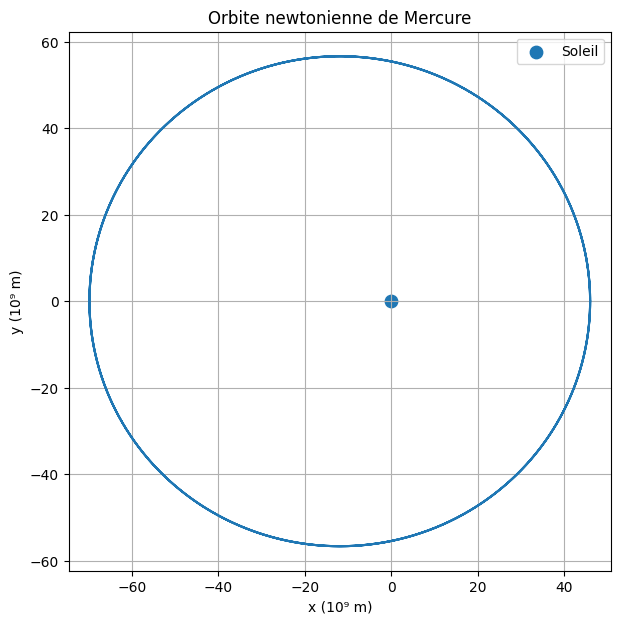

In [7]:

plt.figure(figsize=(7,7))
plt.plot(sol_newton.y[0]/1e9, sol_newton.y[1]/1e9)
plt.scatter([0],[0],s=80,label="Soleil")
plt.xlabel("x (10⁹ m)")
plt.ylabel("y (10⁹ m)")
plt.title("Orbite newtonienne de Mercure")
plt.axis("equal")
plt.grid(True)
plt.legend()
plt.show()



# 4. Précession relativiste de Mercure

Pour une orbite de Schwarzschild dans le plan équatorial, l'équation de Binet relativiste est :

\[
\frac{d^2u}{d\phi^2}
+
u
=
\frac{GM}{h^2}
+
\frac{3GM}{c^2}u^2,
\qquad
u=\frac1r.
\]

La précession faible attendue par orbite est :

\[
\Delta\phi_{\mathrm{GR}}
=
\frac{6\pi GM}{a(1-e^2)c^2}.
\]

Pour éviter l'erreur de grille rencontrée dans la version 0.1, les périastres sont détectés comme événements continus de :

\[
\frac{du}{d\phi}=0.
\]

Un périastre correspond à un maximum de \(u\), donc à un passage de \(u'\) de positif vers négatif.


In [8]:

p_ref = a_ref*(1-e_ref**2)
h2_ref = MU_SUN*p_ref

def schwarzschild_binet(phi, Y):
    u, up = Y
    upp = MU_SUN/h2_ref + 3*MU_SUN*u*u/c**2 - u
    return [up, upp]

def peri_event(phi, Y):
    return Y[1]

peri_event.direction = -1
peri_event.terminal = False

u0 = 1.0/r_peri
Y0 = [u0, 0.0]

# Petit décalage pour ne pas recompter artificiellement l'événement initial
phi_start = 1e-9
Y_start = np.array(Y0) + np.array(schwarzschild_binet(0.0, Y0))*phi_start

sol_gr = solve_ivp(
    schwarzschild_binet,
    (phi_start, 20*2*np.pi),
    Y_start,
    events=peri_event,
    method="DOP853",
    rtol=1e-12,
    atol=1e-15,
    max_step=0.02
)

peri_phi = sol_gr.t_events[0]
peri_phi = peri_phi[peri_phi > 1.0]

delta_per_orbit_num = np.diff(peri_phi) - 2*np.pi
delta_phi_num = delta_per_orbit_num.mean()

delta_phi_ref = 6*np.pi*MU_SUN/(a_ref*(1-e_ref**2)*c**2)

arcsec_per_rad = 206264.80624709636
T_mercury = T_ref
orbits_per_century = (100*365.25*86400)/T_mercury

precession_num_arcsec_century = (
    delta_phi_num*arcsec_per_rad*orbits_per_century
)
precession_ref_arcsec_century = (
    delta_phi_ref*arcsec_per_rad*orbits_per_century
)
precession_rel_error = rel_error(delta_phi_num, delta_phi_ref)

print("Périastres détectés :", len(peri_phi))
print("Précession numérique rad/orbite :", delta_phi_num)
print("Précession théorique rad/orbite :", delta_phi_ref)
print("Numérique arcsec/siècle :", precession_num_arcsec_century)
print("Théorique arcsec/siècle :", precession_ref_arcsec_century)
print("Erreur relative :", precession_rel_error)


Périastres détectés : 19
Précession numérique rad/orbite : 5.018820059790288e-07
Précession théorique rad/orbite : 5.01881905523489e-07
Numérique arcsec/siècle : 42.982744512352966
Théorique arcsec/siècle : 42.982735909026395
Erreur relative : 2.0015772367644944e-07


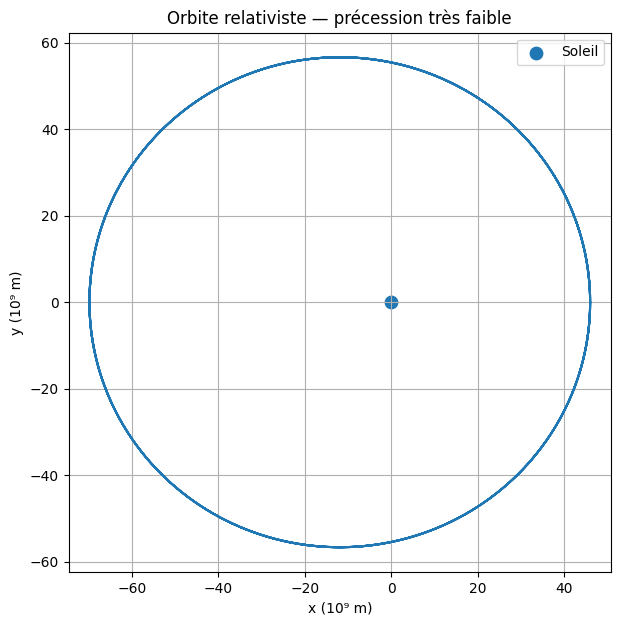

In [9]:

# Visualisation de quelques orbites
phi_plot = np.linspace(0, 8*np.pi, 20000)
sol_gr_plot = solve_ivp(
    schwarzschild_binet,
    (0.0, phi_plot[-1]),
    Y0,
    t_eval=phi_plot,
    method="DOP853",
    rtol=1e-12,
    atol=1e-15,
    max_step=0.02
)

r_gr = 1.0/sol_gr_plot.y[0]
x_gr = r_gr*np.cos(phi_plot)
y_gr = r_gr*np.sin(phi_plot)

plt.figure(figsize=(7,7))
plt.plot(x_gr/1e9, y_gr/1e9)
plt.scatter([0],[0],s=80,label="Soleil")
plt.xlabel("x (10⁹ m)")
plt.ylabel("y (10⁹ m)")
plt.title("Orbite relativiste — précession très faible")
plt.axis("equal")
plt.grid(True)
plt.legend()
plt.show()



# 5. Covariance sous rotation

Une rotation rigide des conditions initiales newtoniennes doit produire la rotation rigide de toute la trajectoire.

Pour une matrice orthogonale \(R\) :

\[
\mathbf r'_0=R\mathbf r_0,
\qquad
\mathbf v'_0=R\mathbf v_0.
\]

Nous vérifions :

\[
\mathbf r'(t)\approx R\mathbf r(t).
\]


In [10]:

def rotation_matrix(axis, angle):
    axis = np.asarray(axis, dtype=float)
    axis /= np.linalg.norm(axis)
    x, y, z = axis
    C = np.cos(angle)
    S = np.sin(angle)
    K = 1-C
    return np.array([
        [C+x*x*K, x*y*K-z*S, x*z*K+y*S],
        [y*x*K+z*S, C+y*y*K, y*z*K-x*S],
        [z*x*K-y*S, z*y*K+x*S, C+z*z*K]
    ])

R = rotation_matrix([1.0, 2.0, 3.0], np.deg2rad(41.0))
y0_rot = np.concatenate([R@y0_newton[:3], R@y0_newton[3:]])

sol_rot = solve_ivp(
    newton_rhs,
    (t_eval[0], t_eval[-1]),
    y0_rot,
    t_eval=t_eval,
    method="DOP853",
    rtol=1e-11,
    atol=1e-12,
    max_step=T_ref/2000
)

reference_rot = R @ sol_newton.y[:3]
rotation_abs_error = np.max(
    np.linalg.norm(sol_rot.y[:3]-reference_rot, axis=0)
)
rotation_rel_error = rotation_abs_error / np.max(
    np.linalg.norm(reference_rot, axis=0)
)

print("Erreur absolue rotation (m) :", rotation_abs_error)
print("Erreur relative rotation :", rotation_rel_error)


Erreur absolue rotation (m) : 0.0035531934150099635
Erreur relative rotation : 5.089308047760396e-14



# 6. Convergence numérique

Une validation n'est pas complète sans étude de convergence.

Nous répétons l'orbite newtonienne avec plusieurs tolérances :

\[
10^{-7},\ 10^{-9},\ 10^{-11},\ 10^{-13}.
\]

La solution la plus précise sert de référence interne.

Nous mesurons l'erreur finale de l'état :

\[
\epsilon
=
\frac{\|Y_{\mathrm{tol}}(T)-Y_{\mathrm{ref}}(T)\|}
{\|Y_{\mathrm{ref}}(T)\|}.
\]


In [11]:

tols = [1e-7, 1e-9, 1e-11, 1e-13]
solutions_final = {}
nfev_rows = []

for tol in tols:
    sol = solve_ivp(
        newton_rhs,
        (0.0, T_ref),
        y0_newton,
        method="DOP853",
        rtol=tol,
        atol=tol*1e-3,
        max_step=T_ref/1000
    )
    solutions_final[tol] = sol.y[:, -1]
    nfev_rows.append((tol, sol.nfev))

reference_final = solutions_final[1e-13]

conv_rows = []
for tol in tols:
    err = np.linalg.norm(solutions_final[tol]-reference_final) / np.linalg.norm(reference_final)
    nfev = dict(nfev_rows)[tol]
    conv_rows.append({
        "rtol": tol,
        "relative_final_state_error": err,
        "nfev": nfev
    })

convergence_df = pd.DataFrame(conv_rows)
convergence_df


,rtol,relative_final_state_error,nfev
0,1.000000e-07,8.087095e-14,12146
1,1.000000e-09,1.376513e-14,12158
2,1.000000e-11,1.946569e-14,12218
3,1.000000e-13,0.000000e+00,12338


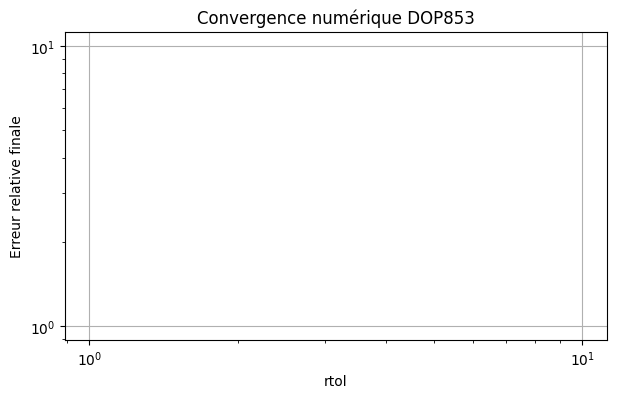

In [12]:

plt.figure(figsize=(7,4))
mask = convergence_df["rtol"] < 1e-13
plt.loglog(
    convergence_df.loc[mask, "rtol"],
    convergence_df.loc[mask, "relative_final_state_error"],
    "o-"
)
plt.xlabel("rtol")
plt.ylabel("Erreur relative finale")
plt.title("Convergence numérique DOP853")
plt.grid(True)
plt.show()



# 7. Interface de comparaison pour une métrique GVH candidate

La validation de référence ne doit pas ajuster arbitrairement une métrique nouvelle.

Une future métrique candidate devra fournir :

\[
A_{\mathrm{GVH}}(\chi),
\qquad
B_{\mathrm{GVH}}(\chi),
\]

avec

\[
\chi=\frac{GM}{c^2r}.
\]

Elle devra ensuite être testée sur exactement les mêmes observables :

- limite plate ;
- accélération newtonienne ;
- période orbitale ;
- précession du périastre ;
- invariance sous rotation ;
- convergence numérique.

La fonction ci-dessous enregistre les coefficients exploratoires sans leur attribuer encore de statut physique.


In [13]:

def gvh_series_coefficients(
    a2=2.0,
    a3=-1.5,
    gamma=1.0,
    b2=1.5,
    b3=0.5
):
    return {
        "a2": float(a2),
        "a3": float(a3),
        "gamma": float(gamma),
        "b2": float(b2),
        "b3": float(b3)
    }

gvh_candidate = gvh_series_coefficients()
gvh_candidate


{'a2': 2.0, 'a3': -1.5, 'gamma': 1.0, 'b2': 1.5, 'b3': 0.5}


# 8. Tableau final de validation

Les seuils ci-dessous sont des critères numériques de travail pour cette version.

Ils pourront être resserrés après exécution sur plusieurs environnements.


In [14]:

thresholds = {
    "minkowski": 1e-8,
    "sphere_constraint": 1e-12,
    "sphere_length": 1e-7,
    "newton_energy": 1e-8,
    "newton_h": 1e-8,
    "newton_period": 1e-6,
    "precession": 5e-3,
    "rotation": 1e-8
}

validation_rows = [
    {
        "test": "Minkowski — trajectoire exacte",
        "mesure": mink_error,
        "seuil": thresholds["minkowski"],
        "statut": "PASS" if mink_error < thresholds["minkowski"] else "CHECK"
    },
    {
        "test": "Sphère — contrainte",
        "mesure": sphere_constraint_error,
        "seuil": thresholds["sphere_constraint"],
        "statut": "PASS" if sphere_constraint_error < thresholds["sphere_constraint"] else "CHECK"
    },
    {
        "test": "Sphère — longueur",
        "mesure": sphere_length_rel_error,
        "seuil": thresholds["sphere_length"],
        "statut": "PASS" if sphere_length_rel_error < thresholds["sphere_length"] else "CHECK"
    },
    {
        "test": "Newton — énergie",
        "mesure": energy_rel_drift,
        "seuil": thresholds["newton_energy"],
        "statut": "PASS" if energy_rel_drift < thresholds["newton_energy"] else "CHECK"
    },
    {
        "test": "Newton — moment cinétique",
        "mesure": h_rel_drift,
        "seuil": thresholds["newton_h"],
        "statut": "PASS" if h_rel_drift < thresholds["newton_h"] else "CHECK"
    },
    {
        "test": "Newton — période",
        "mesure": period_rel_error,
        "seuil": thresholds["newton_period"],
        "statut": "PASS" if period_rel_error < thresholds["newton_period"] else "CHECK"
    },
    {
        "test": "Schwarzschild — précession",
        "mesure": precession_rel_error,
        "seuil": thresholds["precession"],
        "statut": "PASS" if precession_rel_error < thresholds["precession"] else "CHECK"
    },
    {
        "test": "Rotation — covariance",
        "mesure": rotation_rel_error,
        "seuil": thresholds["rotation"],
        "statut": "PASS" if rotation_rel_error < thresholds["rotation"] else "CHECK"
    }
]

validation_df = pd.DataFrame(validation_rows)
validation_df


,test,mesure,seuil,statut
0,Minkowski — trajectoire exacte,5.705287e-13,1.000000e-08,PASS
1,Sphère — contrainte,3.330669e-16,1.000000e-12,PASS
2,Sphère — longueur,1.916768e-09,1.000000e-07,PASS
3,Newton — énergie,9.778883e-15,1.000000e-08,PASS
4,Newton — moment cinétique,5.344587e-15,1.000000e-08,PASS
5,Newton — période,3.989526e-12,1.000000e-06,PASS
6,Schwarzschild — précession,2.001577e-07,5.000000e-03,PASS
7,Rotation — covariance,5.089308e-14,1.000000e-08,PASS


In [15]:

overall_status = (
    "PASS"
    if (validation_df["statut"] == "PASS").all()
    else "CHECK"
)

print("STATUT GLOBAL :", overall_status)


STATUT GLOBAL : PASS



# 9. Interprétation scientifique

## Ce que cette validation peut établir

Si tous les tests passent, le moteur numérique est compatible avec :

- la trajectoire rectiligne locale ;
- la géométrie sphérique globale ;
- la gravitation newtonienne ;
- la correction relativiste de Schwarzschild ;
- l'invariance sous rotation.

## Ce qu'elle n'établit pas

Elle ne démontre pas encore que la géométrie diagonale cubique GVH constitue une théorie physique nouvelle.

En particulier, reproduire exactement Schwarzschild dans des coordonnées cartésiennes isotropes peut être une reformulation de la relativité générale, et non une nouvelle prédiction.

Pour produire un contenu propre à GVH, il faudra :

1. dériver la métrique candidate à partir de principes GVH ;
2. identifier ses paramètres indépendants ;
3. montrer qu'elle conserve les limites validées ;
4. produire au moins une différence observable et falsifiable.



# 10. Étape suivante

Après validation de cette version, la prochaine étape logique est :

\[
\boxed{
\texttt{GVH\_Diagonal\_Cubic\_0.2.5\_Candidate\_Metric\_Tests.ipynb}
}
\]

Elle devra comparer :

\[
g_{\mu\nu}^{\mathrm{GVH}}
\quad \text{contre} \quad
g_{\mu\nu}^{\mathrm{Schwarzschild}},
\]

sans réajuster séparément les paramètres pour chaque observable.

Les tests prioritaires seront :

1. précession du périastre ;
2. déviation de la lumière ;
3. retard de Shapiro ;
4. décalage gravitationnel vers le rouge ;
5. comportement en champ fort ;
6. covariance complète sous rotation.
